In [1]:
import pandas as pd
import numpy as np

print("Setup successful!")

Setup successful!


In [13]:
# sheet_name=1 targets the actual list of transactions usually following the overview sheet
df_sessions = pd.read_excel(
    "../data/Ladevorgänge_Ladeinfrastruktur_Beispiel_Ladehub.xlsx", 
    sheet_name=1
)

#Transformer Load Profile 
# Row 0 contains tracking metadata. Header is at Row 1.
df_load = pd.read_excel(
    "../data/Lastgang_Ladeinfrastruktur_Beispiel_Ladehub.xlsx", 
    header=1
)

#Spot Market Prices 
df_spot = pd.read_excel("../data/Spotmarktpreis_.xlsx")

print("Data successfully loaded!")

Data successfully loaded!


In [18]:
# Standardize Charging Sessions
df_sessions['Gestartet'] = pd.to_datetime(df_sessions['Gestartet'])
df_sessions['Beendet'] = pd.to_datetime(df_sessions['Beendet'])
df_sessions['Hour_Started'] = df_sessions['Gestartet'].dt.hour
df_sessions['Month_Year'] = df_sessions['Gestartet'].dt.to_period('M')

# Standardize Load Profiles
df_load['Timestamp'] = pd.to_datetime(df_load['Ab-Datum'].astype(str) + ' ' + df_load['Ab-Zeit'].astype(str))
df_load['Hour'] = df_load['Timestamp'].dt.hour

# Standardize Spot Market Prices
df_spot['Timestamp'] = pd.to_datetime(df_spot['Datum'].astype(str) + ' ' + df_spot['von'].astype(str))
df_spot['Hour'] = df_spot['Timestamp'].dt.hour
# Spot market files sometimes scale prices per MWh or use commas; let's ensure it is numerical in ct/kWh
df_spot['Spotmarktpreis in ct/kWh'] = pd.to_numeric(df_spot['Spotmarktpreis in ct/kWh'], errors='coerce')

print("Data cleaning complete!")

Data cleaning complete!


In [19]:
print("--- TIME OF DAY ANALYSIS ---")
# Peak Grid Utilization Time
avg_hourly_grid = df_load.groupby('Hour')['Profilwert\nkW'].mean()
print(f"Peak transformer load typically happens at hour: {avg_hourly_grid.idxmax()}:00 ({avg_hourly_grid.max():.2f} kW)")

# Peak Session Inception Time
sessions_by_hour = df_sessions['Hour_Started'].value_counts().sort_index()
print(f"Most drivers plug in at hour: {sessions_by_hour.idxmax()}:00 ({sessions_by_hour.max()} sessions)")

--- TIME OF DAY ANALYSIS ---
Peak transformer load typically happens at hour: 17:00 (73.38 kW)
Most drivers plug in at hour: 17:00 (1346 sessions)


In [20]:
print("\n--- SPOT PRICE MARKET INSIGHTS ---")
avg_hourly_spot = df_spot.groupby('Hour')['Spotmarktpreis in ct/kWh'].mean()

print(f"Cheapest baseline electricity window: {avg_hourly_spot.idxmin()}:00 ({avg_hourly_spot.min():.4f} ct/kWh)")
print(f"Most expensive procurement window: {avg_hourly_spot.idxmax()}:00 ({avg_hourly_spot.max():.4f} ct/kWh)")


--- SPOT PRICE MARKET INSIGHTS ---
Cheapest baseline electricity window: 13:00 (4.1138 ct/kWh)
Most expensive procurement window: 19:00 (13.0761 ct/kWh)


In [17]:
print("\n--- PROFITABILITY BASELINE ANALYSIS ---")
# Aggregate wholesale energy costs from the spot price data
avg_market_cost_ct = df_spot['Spotmarktpreis in ct/kWh'].mean() # in cents
avg_market_cost_eur = avg_market_cost_ct / 100 # converted to Euros

# Sample Fixed-Price Tariff baseline calculation (e.g., if you charged flat 45 cents/kWh)
assumed_flat_revenue_per_kwh = 0.45 
total_kwh_delivered = df_sessions['Verbrauch (kWh)'].sum()

estimated_revenue = total_kwh_delivered * assumed_flat_revenue_per_kwh
estimated_wholesale_cost = total_kwh_delivered * avg_market_cost_eur
gross_profit_baseline = estimated_revenue - estimated_wholesale_cost

print(f"Total Energy Delivered: {total_kwh_delivered:,.2f} kWh")
print(f"Estimated Gross Revenue (at Flat €0.45/kWh): €{estimated_revenue:,.2f}")
print(f"Estimated Pure Wholesale Energy Cost: €{estimated_wholesale_cost:,.2f}")
print(f"Baseline Spread Profit (Excl. Grid Fees): €{gross_profit_baseline:,.2f}")


--- PROFITABILITY BASELINE ANALYSIS ---
Total Energy Delivered: 442,492.49 kWh
Estimated Gross Revenue (at Flat €0.45/kWh): €199,121.62
Estimated Pure Wholesale Energy Cost: €36,780.40
Baseline Spread Profit (Excl. Grid Fees): €162,341.22


Parsing and loading sheets from ../data/ ...
✨ Data successfully loaded and cleaned from original Excel sources!

--- SUMMARY STATS ---
Total Charging Sessions analyzed: 13155
Absolute Peak Transformer Grid Load: 393.60 kW
Average Spot Market Electricity Price: 8.31 ct/kWh


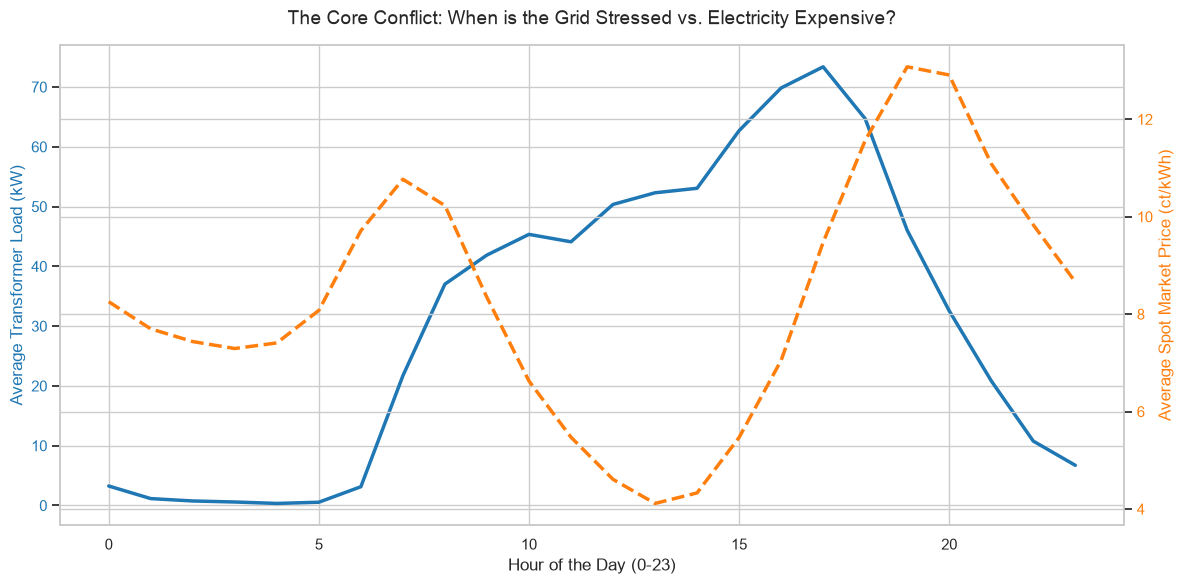

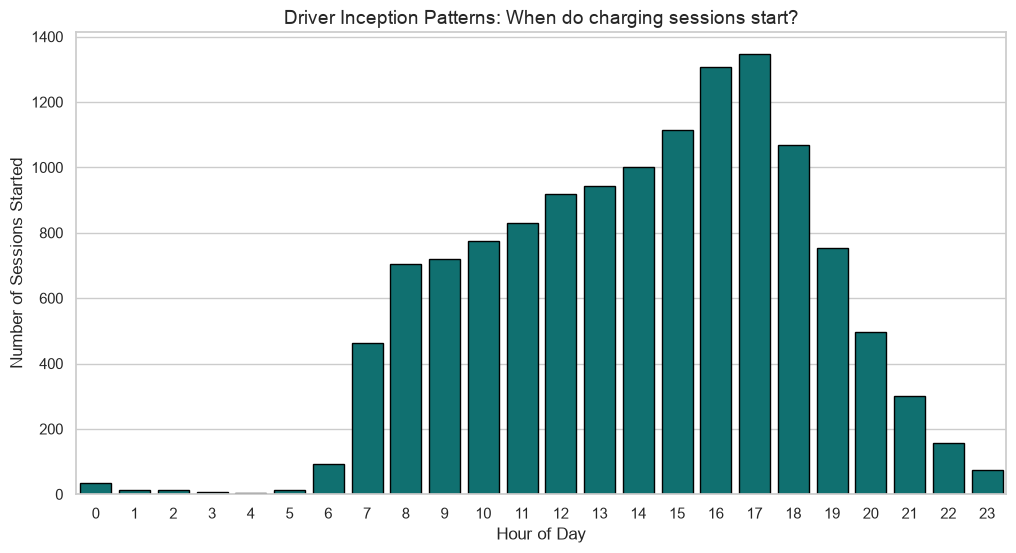

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]

# 1. LOAD & CLEAN DATA (Using direct Excel paths relative to backend/)
print("Parsing and loading sheets from ../data/ ...")

# 1.1 Load Charging Sessions (Sheet index 1 has the itemized records)
df_sessions = pd.read_excel("../data/Ladevorgänge_Ladeinfrastruktur_Beispiel_Ladehub.xlsx", sheet_name=1)
df_sessions['Gestartet'] = pd.to_datetime(df_sessions['Gestartet'], errors='coerce')
df_sessions['Hour'] = df_sessions['Gestartet'].dt.hour
df_sessions['Weekday'] = df_sessions['Gestartet'].dt.day_name()

# 1.2 Load Transformer Grid Load (Header starts at line 1)
df_load = pd.read_excel("../data/Lastgang_Ladeinfrastruktur_Beispiel_Ladehub.xlsx", header=1)
df_load['Timestamp'] = pd.to_datetime(df_load['Ab-Datum'].astype(str) + ' ' + df_load['Ab-Zeit'].astype(str), errors='coerce')
df_load['Hour'] = df_load['Timestamp'].dt.hour

# Clean numeric values if they are formatted as strings with commas
if df_load['Profilwert\nkW'].dtype == 'O':
    df_load['Profilwert\nkW'] = df_load['Profilwert\nkW'].astype(str).str.replace(',', '.').astype(float)

# 1.3 Load Spot Market Prices
df_spot = pd.read_excel("../data/Spotmarktpreis_.xlsx")
df_spot['Timestamp'] = pd.to_datetime(df_spot['Datum'].astype(str) + ' ' + df_spot['von'].astype(str), errors='coerce')
df_spot['Hour'] = df_spot['Timestamp'].dt.hour

if df_spot['Spotmarktpreis in ct/kWh'].dtype == 'O':
    df_spot['Spotmarktpreis in ct/kWh'] = df_spot['Spotmarktpreis in ct/kWh'].astype(str).str.replace(',', '.').astype(float)

print("✨ Data successfully loaded and cleaned from original Excel sources!\n")

# 2. PRINT VISUAL METRICS
print("--- SUMMARY STATS ---")
print(f"Total Charging Sessions analyzed: {len(df_sessions)}")
print(f"Absolute Peak Transformer Grid Load: {df_load['Profilwert\nkW'].max():.2f} kW")
print(f"Average Spot Market Electricity Price: {df_spot['Spotmarktpreis in ct/kWh'].mean():.2f} ct/kWh")


# 3. VISUALIZATION 1: Time of Day Bottlenecks (Grid vs Market Costs)
fig, ax1 = plt.subplots()

# Line 1: Average Transformer Load Profile by Hour
hourly_grid = df_load.groupby('Hour')['Profilwert\nkW'].mean()
color = '#1f77b4'
ax1.set_xlabel('Hour of the Day (0-23)')
ax1.set_ylabel('Average Transformer Load (kW)', color=color)
ax1.plot(hourly_grid.index, hourly_grid.values, color=color, linewidth=2.5, label='Transformer Load (kW)')
ax1.tick_params(axis='y', labelcolor=color)

# Line 2: Average Spot Price by Hour (on a secondary Y-axis)
ax2 = ax1.twinx()
hourly_spot = df_spot.groupby('Hour')['Spotmarktpreis in ct/kWh'].mean()
color = '#ff7f0e'
ax2.set_ylabel('Average Spot Market Price (ct/kWh)', color=color)
ax2.plot(hourly_spot.index, hourly_spot.values, color=color, linewidth=2.5, linestyle='--', label='Spot Price (ct/kWh)')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('The Core Conflict: When is the Grid Stressed vs. Electricity Expensive?', fontsize=14, pad=15)
fig.tight_layout()
plt.show()

# 4. VISUALIZATION 2: Driver Demand (When do people actually plug in?)
plt.figure()
sns.countplot(data=df_sessions, x='Hour', color='teal', edgecolor='black')
plt.title('Driver Inception Patterns: When do charging sessions start?', fontsize=14)
plt.xlabel('Hour of Day')
plt.ylabel('Number of Sessions Started')
plt.show()

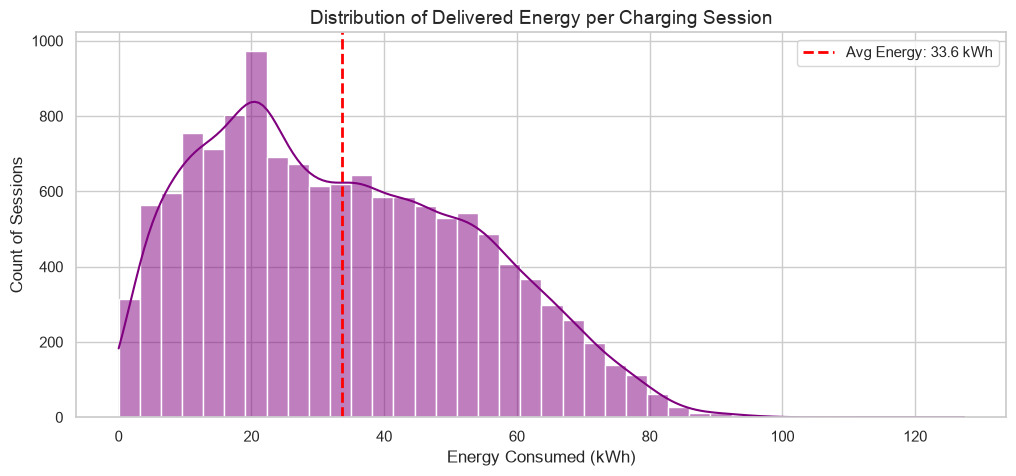

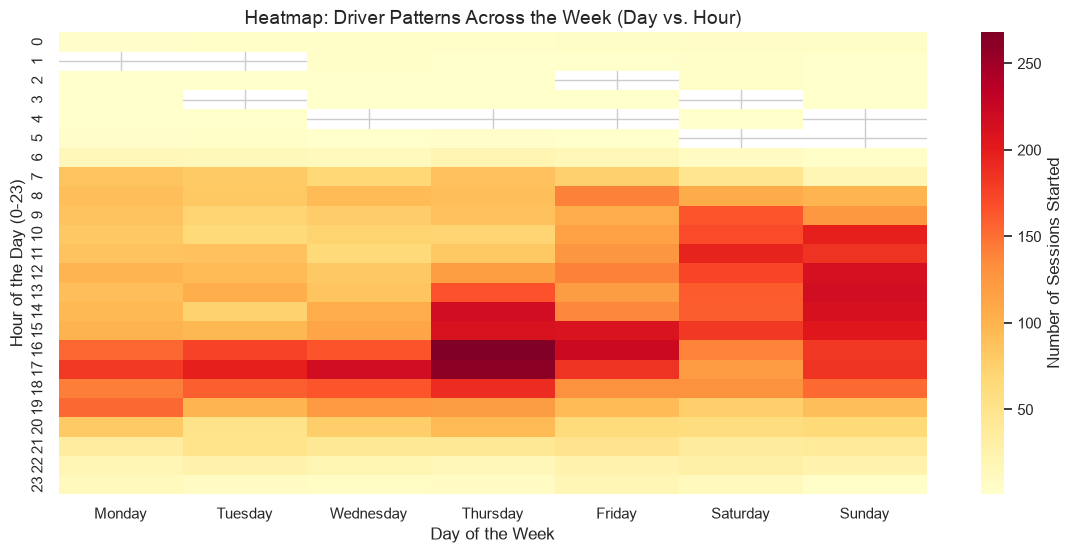

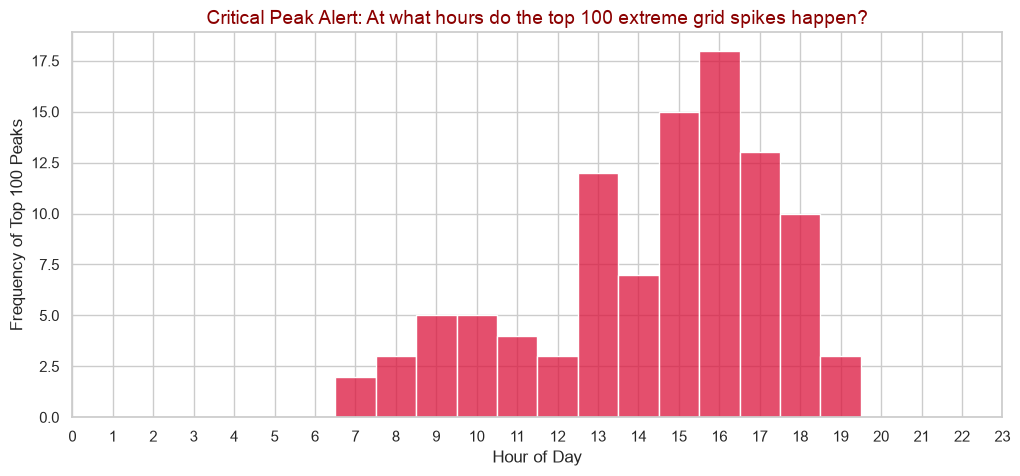

In [26]:
# VISUALIZATION 3: Distribution of Session Sizes & Power Demands
# Target: Understand how much energy cars actually request when they plug in.
plt.figure(figsize=(12, 5))
sns.histplot(data=df_sessions, x='Verbrauch (kWh)', bins=40, color='purple', kde=True)
plt.axvline(df_sessions['Verbrauch (kWh)'].mean(), color='red', linestyle='--', linewidth=2, 
            label=f"Avg Energy: {df_sessions['Verbrauch (kWh)'].mean():.1f} kWh")

plt.title('Distribution of Delivered Energy per Charging Session', fontsize=14)
plt.xlabel('Energy Consumed (kWh)')
plt.ylabel('Count of Sessions')
plt.legend()
plt.show()


# VISUALIZATION 4: Day of the Week Bottlenecks
# Target: See if weekdays vs. weekends change the hub profile entirely.
# Group sessions by day of week and hour
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df_sessions['Weekday'] = pd.to_datetime(df_sessions['Gestartet']).dt.day_name()

pivot_sessions = df_sessions.groupby(['Weekday', 'Hour']).size().unstack(level=0)[day_order]

plt.figure(figsize=(14, 6))
sns.heatmap(pivot_sessions, cmap='YlOrRd', cbar_kws={'label': 'Number of Sessions Started'})
plt.title('Heatmap: Driver Patterns Across the Week (Day vs. Hour)', fontsize=14)
plt.xlabel('Day of the Week')
plt.ylabel('Hour of the Day (0-23)')
plt.show()

# VISUALIZATION 5: High-Resolution Peak Grid Analysis (Top 1% Peaks)
# Target: Spot the absolute worst peaks that cause high Transformer Charges.

plt.figure(figsize=(12, 5))
# Sort loads to look at the top 100 highest 15-minute grid load spikes
top_peaks = df_load.sort_values(by='Profilwert\nkW', ascending=False).head(100)

sns.histplot(data=top_peaks, x='Hour', bins=24, color='crimson', discrete=True)
plt.title('Critical Peak Alert: At what hours do the top 100 extreme grid spikes happen?', fontsize=14, color='darkred')
plt.xlabel('Hour of Day')
plt.ylabel('Frequency of Top 100 Peaks')
plt.xticks(range(0, 24))
plt.show()

In [3]:
!ls data



ls: data: No such file or directory


In [4]:
!ls ../data

Ladevorgänge_Ladeinfrastruktur_Beispiel_Ladehub.xlsx
Lastgang_Ladeinfrastruktur_Beispiel_Ladehub.xlsx
Spotmarktpreis_.xlsx


In [9]:
pd.read_excel("../data/Lastgang_Ladeinfrastruktur_Beispiel_Ladehub.xlsx")

,Kopfdaten des Profils,Unnamed: 1,Unnamed: 2,Unnamed: 3,Profilwerte,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Status der Profilwerte,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15
0,Nummer des EDM-Profils,000000000011069551,NaN,Monat,Ab-Datum,Ab-Zeit,Profilwert\nkWh,Profilwert\nkW,NaN,Ab-Datum,Ab-Zeit,Bis-Datum,Bis-Zeit,Status oder Vorgang,Text,Langtext
1,Bezeichnung des Profils,Wirk 1-1:1.29.0 51265218251,NaN,1,2025-01-01 00:00:00,00:00:00,0.1,0.4,NaN,2025-01-01 00:00:00,00:00:00,2025-12-31 00:00:00,23:59:59,IU012,WGÜ,Wert ist gültig
2,Profilart,Gemessenes Profil,NaN,1,2025-01-01 00:00:00,00:15:00,0.05,0.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Profilwertetyp,MENGE,NaN,1,2025-01-01 00:00:00,00:30:00,0.1,0.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Zeitzone,CET,NaN,1,2025-01-01 00:00:00,00:45:00,0.1,0.4,NaN,NaN,Verbrauch kWh,Max kW,Min kW,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35036,NaN,NaN,NaN,12,2025-12-31 00:00:00,22:45:00,0.1,0.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
35037,NaN,NaN,NaN,12,2025-12-31 00:00:00,23:00:00,0.1,0.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
35038,NaN,NaN,NaN,12,2025-12-31 00:00:00,23:15:00,0.1,0.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
35039,NaN,NaN,NaN,12,2025-12-31 00:00:00,23:30:00,4.35,17.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
pd.read_excel("../data/Spotmarktpreis_.xlsx")

,Datum,von,Zeitzone von,bis,Zeitzone bis,Spotmarktpreis in ct/kWh
0,2024-01-01,00:00:00,CET,01:00:00,CET,0.010
1,2024-01-01,01:00:00,CET,02:00:00,CET,0.001
2,2024-01-01,02:00:00,CET,03:00:00,CET,0.000
3,2024-01-01,03:00:00,CET,04:00:00,CET,-0.001
4,2024-01-01,04:00:00,CET,05:00:00,CET,-0.003
...,...,...,...,...,...,...
15330,2025-09-30,19:00:00,CEST,20:00:00,CEST,35.777
15331,2025-09-30,20:00:00,CEST,21:00:00,CEST,14.728
15332,2025-09-30,21:00:00,CEST,22:00:00,CEST,11.604
15333,2025-09-30,22:00:00,CEST,23:00:00,CEST,10.163
